In [3]:
import pandas as pd
import numpy as np
from keras.src.losses import mean_absolute_error
from tensorflow.python.keras.engine.input_layer import InputLayer

dataset = 'final_year_project_mock_traffic_data.csv'
df =pd.read_csv(dataset)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           400 non-null    str    
 1   lane_1_avg_density  400 non-null    float64
 2   lane_1_volume       400 non-null    int64  
 3   lane_2_avg_density  400 non-null    float64
 4   lane_2_volume       400 non-null    int64  
 5   lane_3_avg_density  400 non-null    float64
 6   lane_3_volume       400 non-null    int64  
 7   lane_4_avg_density  400 non-null    float64
 8   lane_4_volume       400 non-null    int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 28.3 KB


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp']) # Make Timestamp readable
print(df.isnull().sum())

# Feature Selection
features = [
    "lane_1_avg_density",
    "lane_1_volume",
    "lane_2_avg_density",
    "lane_2_volume",
    "lane_3_avg_density",
    "lane_3_volume",
    "lane_4_avg_density",
    "lane_4_volume"
]
X = df[features]
X.shape

timestamp             0
lane_1_avg_density    0
lane_1_volume         0
lane_2_avg_density    0
lane_2_volume         0
lane_3_avg_density    0
lane_3_volume         0
lane_4_avg_density    0
lane_4_volume         0
dtype: int64


(400, 8)

In [5]:
def create_sequences(data, sequence_length):
    # Initialize empty lists to hold input sequences (X) and targets (y)
    X_sequences = []
    y = []

    # Loop through the dataset, stopping before the last 'sequence_length' elements
    for i in range(len(data) - sequence_length):
        # Take a slice of 'sequence_length' values as one input sequence
        X_sequences.append(data[i:i + sequence_length])

        # The target (label) is the value immediately after the sequence
        y.append(data[i + sequence_length])

    # Convert lists into NumPy arrays for ML model compatibility
    return np.array(X_sequences), np.array(y)

In [6]:
train_size = int(len(X) * 0.8 ) #Use 80% of data for training and 20 for testing
X_train, X_test = X.iloc[0:train_size], X.iloc[train_size:]
X_train.shape, X_test.shape


((320, 8), (80, 8))

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Uses fit_transform , so the scaler can learn min and max
X_test_scaled = scaler.transform(X_test)  # use transform so there is no learning here

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (320, 8)
X_test_scaled: (80, 8)


In [8]:
sequence_length = 10
X_train_seq , y_train = create_sequences(X_train_scaled, sequence_length)
X_test_seq , y_test = create_sequences(X_test_scaled, sequence_length)

# 4. Check shapes
print("X_train_seq:", X_train_seq.shape)
print("y_train:", y_train.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test:", y_test.shape)

X_train_seq: (310, 10, 8)
y_train: (310, 8)
X_test_seq: (70, 10, 8)
y_test: (70, 8)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([LSTM(64, input_shape=(10, 8)), Dense(8)])
model.compile(loss='mse', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,208 (75.03 KB)

 Trainable params: 19,208 (75.03 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train_seq,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.1111 - loss: 0.2070 - val_accuracy: 0.0968 - val_loss: 0.2246
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1326 - loss: 0.0579 - val_accuracy: 0.1613 - val_loss: 0.0304
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3047 - loss: 0.0304 - val_accuracy: 0.2581 - val_loss: 0.0368
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3835 - loss: 0.0273 - val_accuracy: 0.2581 - val_loss: 0.0354
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3190 - loss: 0.0219 - val_accuracy: 0.2581 - val_loss: 0.0217
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2545 - loss: 0.0202 - val_accuracy: 0.3548 - val_loss: 0.0236
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3728 - loss: 0.0185 - val_accuracy: 0.3871 - val_loss: 0.0195
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4158 - loss: 0.0177 - val_accuracy: 0.3226 - val_loss: 0.0190


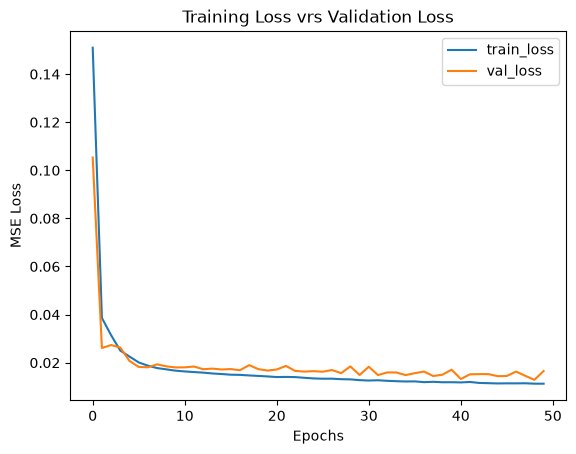

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training Loss vrs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [15]:
y_pred_scaled = model.predict(X_test_seq)
print(y_pred_scaled.shape)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_original = scaler.inverse_transform(y_test)

print("Predicted:", y_pred[0])
print("\nActual:", y_test_original[0])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
(70, 8)
Predicted: [ 14.032059  183.82579    19.953653  141.24438     7.5290008  92.74569
  23.722452  135.29793  ]

Actual: [ 14.92 194.    19.25 132.     6.9   87.    23.93 126.  ]


In [18]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(np.mean((y_test_original - y_pred) ** 2))
print("MAE:", mae)
print("RMSE:", rmse)


MAE: 5.096788226400102
RMSE: 8.359130770832936
